# 5073 - Lengoaiak eta Datu Zientzia
## 2. Gaia: Datu Zientziaren Tresnak (PDF-ko Ariketa Guztien Ebazpena)

Dokumentu honek `5073_2_Datu_Zientzia.pdf` apunteetako **ariketa praktiko guztiak** biltzen eta ebazten ditu:
1. **NumPy**:
   - **Ariketa 1.1**: Python zerrenden vs NumPy array-en abiadura benchmark-a ($N=10^6, 10^7, 50 \times 10^6$).
   - **Ariketa 1.2**: 2D Notak Matrizea (6 ikasle $\times$ 4 azterketa) eta estatistikak ardatzen arabera.
   - **Ariketa 1.3**: BEZ / Marjinen kalkulua begiztarik gabe (Broadcasting).
   - **Ariketa 1.4**: Stock kritikoaren filtrazioa (Boolean Indexing) eta berrezartze kalkulua.
   - **Ariketa 1.5**: 3 Denda $\times$ 4 Hiruhileko Salmenten agregazioak (`axis=0` vs `axis=1`).
2. **Pandas**:
   - **Ariketa 2.1**: Langileen DataFrame-a, iragazki aurreratuak eta 14 ordainsariko urteko soldata.
   - **Ariketa 2.2**: 3 hilabetetako salmenta CSVak kargatu eta pilatu (`pd.concat`).
   - **Ariketa 2.3**: Datu zikinen garbiketa pipeline osoa (null-ak, bikoiztuak, espazioak, formatuak).
   - **Ariketa 2.4**: Agregazio konplexuak (`groupby` anizkoitzak eta `pivot_table`).
   - **Ariketa 2.5**: Eredu erlazionala eta taulen batzea (`merge` Inner/Left vs `concat`).
3. **Matplotlib eta Seaborn**:
   - **Ariketa 3.1**: Matplotlib 2x2 azpigrafikoak (barrak, sakabanaketa, histograma, boxplot) eta esportazioa (PNG/PDF).
   - **Ariketa 3.2**: Seaborn estatistika-bistaratzea eta Korrelazio Heatmap-a `tips` datu-multzoarekin.
   - **Ariketa 3.3**: Gaiak, paletak (`muted`, `husl`), tamaina (`font_scale`) eta esportazio bektoriala (SVG, PDF, PNG).
4. **DVC (Data Version Control)**:
   - **Ariketa 4.1**: Git + DVC laborategia, `notak.csv` bertsionatzea, remote lokala eta biltegiratzea.
5. **Plataforma Komertzialak**:
   - **Ariketa 5.1**: Azure ML, IBM Watson, Knime vs Python konparaketa matrizea 3 enpresa motarentzat.

---
## 1. NumPy: Zenbakizko Kalkulua
### 🧩 Ariketa 1.1 · Python List vs NumPy Array Abiadura Benchmark-a
**Egoera:** Python-eko ohiko zerrenden eta NumPy array optimizatuen arteko errendimendu-aldea neurtu behar dugu tamaina handiekin:
$N \in [1\,000\,000, 10\,000\,000, 50\,000\,000]$.

**Eginkizuna:**
1. Elementuen batuketa neurtu Python pure (`sum(range(N))`) eta NumPy bektorialarekin (`np.sum(np.arange(N))`).
2. Exekuzio-denborak neurtu eta abiadura-faktorea (*Speedup*) kalkulatu.
3. Emaitzak taula egituratu batean bistaratu eta CSV batean gorde.

In [1]:
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from laguntzaileak import pilatu_csvak


In [2]:
N_BALIOAK = [1_000_000, 10_000_000, 50_000_000]
BENCHMARK_CSV = Path("data/emaitzak_benchmark.csv")


def neurtu_batura(n: int) -> dict:
    """Elementu-batura Python pure vs NumPy: denborak + speedup."""
    hasiera_py = time.perf_counter()
    batura_py = sum(range(n))
    denbora_py = time.perf_counter() - hasiera_py

    arr = np.arange(n, dtype=np.int64)
    hasiera_np = time.perf_counter()
    batura_np = np.sum(arr)
    denbora_np = time.perf_counter() - hasiera_np

    assert batura_py == int(batura_np), "Emaitzak ez datoz bat!"
    return {
        "Elementuak (N)": f"{n:,}",
        "Python (s)": round(denbora_py, 4),
        "NumPy (s)": round(denbora_np, 4),
        "Speedup": f"{denbora_py / denbora_np:.2f}x",
    }


def ariketa_1_1() -> pd.DataFrame:
    """Python List vs NumPy Array abiadura benchmark-a."""
    df_bench = pd.DataFrame([neurtu_batura(n) for n in N_BALIOAK])
    df_bench.to_csv(BENCHMARK_CSV, index=False)
    print("=== ARIKETA 1.1: ABIADURA BENCHMARK EMAITZAK ===")
    print(df_bench.to_string(index=False))
    print(
        "\nOharra: Ikus daitekeenez, NumPy 10x-50x azkarragoa da, C lengoaian konpilatutako memoria-bloke trinkoak eta SIMD bektorializazioa erabiltzen dituelako."
    )
    return df_bench


---
### 🧩 Ariketa 1.2 · 2D Notak Matrizea (6 ikasle $\times$ 4 azterketa)
**Egoera:** Klase bateko 6 ikasleren 4 azterketako notak matrize batean dituzu.  
**Eginkizuna:**
1. Sortu $(6, 4)$ formako matrizea.
2. Kalkulatu ikasle bakoitzaren batezbestekoa (`axis=1`).
3. Kalkulatu azterketa bakoitzeko batezbestekoa (`axis=0`).
4. Aurkitu zein izan den azterketarik zailena (batezbesteko txikiena).
5. Kalkulatu ikasle guztien artean gainditu diren azterketa kopuru osoa (notak $\ge 5.0$).

In [3]:
NOTAK = np.array(
    [
        [8.5, 7.0, 9.0, 8.0],  # Ikasle 1 (Ane)
        [4.0, 5.5, 3.5, 6.0],  # Ikasle 2 (Mikel)
        [9.0, 8.5, 9.5, 9.0],  # Ikasle 3 (Leire)
        [6.0, 4.5, 7.0, 5.5],  # Ikasle 4 (Jon)
        [7.5, 8.0, 8.5, 9.0],  # Ikasle 5 (Maite)
        [3.5, 5.0, 4.0, 6.0],  # Ikasle 6 (Kepa)
    ]
)
IKASLEAK = ["Ane", "Mikel", "Leire", "Jon", "Maite", "Kepa"]
AZTERKETAK = ["Azterketa 1", "Azterketa 2", "Azterketa 3", "Azterketa 4"]
GAINDITZE_MUGA = 5.0


def ariketa_1_2() -> dict:
    """2D notak: batezbestekoak ardatzetan, zailena, gaindituak."""
    ikasle_bb = np.mean(NOTAK, axis=1)
    azterketa_bb = np.mean(NOTAK, axis=0)
    zailena_idx = int(np.argmin(azterketa_bb))
    gaindituak = int(np.sum(NOTAK >= GAINDITZE_MUGA))

    print("=== ARIKETA 1.2 EMAITZAK ===")
    print("1. Ikasle bakoitzaren batezbestekoa:")
    for ikasle, bb in zip(IKASLEAK, ikasle_bb):
        print(f"   - {ikasle:8}: {bb:.2f}")
    print("\n2. Azterketa bakoitzeko batezbestekoa:")
    for azterketa, bb in zip(AZTERKETAK, azterketa_bb):
        print(f"   - {azterketa}: {bb:.2f}")
    print(
        f"\n3. Azterketarik zailena: {AZTERKETAK[zailena_idx]} (Batezbestekoa: {azterketa_bb[zailena_idx]:.2f})"
    )
    print(
        f"4. Gainditutako probak guztira: {gaindituak} / {NOTAK.size} (%{(gaindituak / NOTAK.size) * 100:.1f})"
    )
    return {
        "ikasle_bb": ikasle_bb,
        "azterketa_bb": azterketa_bb,
        "gaindituak": gaindituak,
    }


---
### 🧩 Ariketa 1.3 · BEZ eta Marjinen Kalkulua (Broadcasting)
**Egoera:** Denda-kate batek 4 produkturen oinarrizko prezioak ditu, eta 3 saltoki desberdinetan aplikatu beharreko BEZ/marjina faktoreak aplikatu nahi ditu begiztarik gabe (*loop-free*).

**Eginkizuna:**
- Oinarrizko prezioak: `[10.0, 25.5, 4.2, 50.0]` euro $\rightarrow$ forma: `(4, 1)`.
- Denden marjinak/tasa faktoreak: `[1.21, 1.10, 1.04]` (BEZ orokorra, murriztua, super-murriztua) $\rightarrow$ forma: `(1, 3)`.
- Kalkulatu amaierako prezioen matrizea $(4, 3)$ broadcasting bidez.

In [4]:
OINARRIZKO_PREZIOAK = np.array([10.0, 25.50, 4.20, 50.00]).reshape(4, 1)
DENDA_FAKTOREAK = np.array([1.21, 1.10, 1.04]).reshape(1, 3)
PRODUKTUEN_IZENAK = ["Sagua", "Teklatua", "Kablea", "Monitorea"]
DENDEN_IZENAK = ["Denda A (%21 BEZ)", "Denda B (%10 BEZ)", "Denda C (%4 BEZ)"]


def ariketa_1_3() -> pd.DataFrame:
    """Broadcasting: (4, 1) * (1, 3) -> (4, 3) prezioen matrizea."""
    amaierako_prezioak = OINARRIZKO_PREZIOAK * DENDA_FAKTOREAK
    df_prezioak = pd.DataFrame(
        amaierako_prezioak, index=PRODUKTUEN_IZENAK, columns=DENDEN_IZENAK
    )
    print("=== ARIKETA 1.3: BROADCASTING PREZIOEN MATRIZEA ===")
    print(df_prezioak.round(2))
    print(f"\nMatrizearen forma (shape): {amaierako_prezioak.shape}")
    return df_prezioak


---
### 🧩 Ariketa 1.4 · Stock Kritikoa (Boolean Indexing)
**Egoera:** Biltegi bateko 10 produkturen stock-a daukazu: `[5, 12, 8, 30, 2, 15, 7, 45, 9, 20]`.  
**Eginkizuna:**
1. Identifikatu stock kritikoa duten produktuak (kopurua $< 10$).
2. Kalkulatu zenbat produktu dauden egoera kritikoan.
3. Sortu hornitze-agindu automatikoa: produktu kritikoak 50 unitatera iristeko behar den kopurua kalkulatu (`np.where`).

In [5]:
STOCK = np.array([5, 12, 8, 30, 2, 15, 7, 45, 9, 20])
STOCK_MUGA = 10
STOCK_HELBURUA = 50


def ariketa_1_4() -> dict:
    """Stock kritikoa: maskara boolearra + hornitze-agindua (`np.where`)."""
    produktu_id = np.arange(101, 111)
    kritiko_maskara = STOCK < STOCK_MUGA
    hornitze_eskaera = np.where(STOCK < STOCK_MUGA, STOCK_HELBURUA - STOCK, 0)
    print("=== ARIKETA 1.4: STOCK KRITIKOAREN AZTERKETA ===")
    print(f"Stock array osoa: {STOCK}")
    print(f"Produktu kritikoen kopurua: {np.sum(kritiko_maskara)} / {len(STOCK)}")
    print(f"Kritikoen IDak: {produktu_id[kritiko_maskara].tolist()}")
    print(f"Kritikoen uneko stock-a: {STOCK[kritiko_maskara].tolist()}")
    print(f"Hornitze agindu bektorea (50 unitateraino): {hornitze_eskaera.tolist()}")
    return {"kritikoak": int(np.sum(kritiko_maskara)), "eskaera": hornitze_eskaera}


---
### 🧩 Ariketa 1.5 · 3 Denda $\times$ 4 Hiruhileko Salmentak (Agregazioak & Ardatzak)
**Egoera:** Hiru dendaren lau hiruhilekoko salmenta-matrizea (milaka eurotan):
```python
np.array([[120, 135, 150, 165], [90, 95, 110, 100], [200, 210, 195, 220]])
```

**Eginkizuna:**
1. Kalkulatu denda bakoitzaren urteko salmenta osoa (`axis=1`).
2. Kalkulatu hiruhileko bakoitzeko batezbesteko salmenta dendetan zehar (`axis=0`).
3. Aurkitu zein dendak duen salmenta-aldakortasun handiena (desbideratze estandarra, `std`).
4. Azaldu: *Zein axis erabili duzu kasu bakoitzean, eta zergatik?*

In [6]:
SALMENTAK_DEND_AT = np.array(
    [
        [120, 135, 150, 165],  # Denda 1
        [90, 95, 110, 100],  # Denda 2
        [200, 210, 195, 220],  # Denda 3
    ]
)


def ariketa_1_5() -> dict:
    """Agregazioak ardatzetan: urtekoa (axis=1), hiruhilekoa (axis=0), aldakortasuna."""
    urtekoak = np.sum(SALMENTAK_DEND_AT, axis=1)
    hiruhileko_bb = np.mean(SALMENTAK_DEND_AT, axis=0)
    aldakortasuna = np.std(SALMENTAK_DEND_AT, axis=1)
    aldakorrena = int(np.argmax(aldakortasuna))
    print("=== ARIKETA 1.5 EMAITZAK ===")
    for i, (salm, std_val) in enumerate(zip(urtekoak, aldakortasuna), 1):
        print(
            f"🏪 Denda {i}: Urteko salmenta = {salm}k € | Desbideratze est. = {std_val:.2f}"
        )
    print("\n📊 Hiruhileko bakoitzeko batezbestekoa (dendetan zehar):")
    for q, bb in enumerate(hiruhileko_bb, 1):
        print(f"   - Q{q}: {bb:.2f}k €")
    print(
        f"\n📈 Aldakortasun handiena duen denda: Denda {aldakorrena + 1} ({aldakortasuna[aldakorrena]:.2f}k €)"
    )
    return {"urtekoak": urtekoak, "aldakorrena": aldakorrena}


### 💡 Ardatzen (axis) Azalpen Metodologikoa:
- **`axis=1` (Errenkaden norabidean)**: Errenkada bakoitzeko zutabe guztiak agregatzen ditu (lau hiruhilekoak elkartuz). Ondorioz, zutabeen dimentsioa desagertzen da eta denda bakoitzeko balio bakar bat lortzen da (forma: `(3,)`).
- **`axis=0` (Zutabeen norabidean)**: Zutabe bakoitzeko errenkada guztiak agregatzen ditu (hiru dendak elkartuz). Ondorioz, errenkaden dimentsioa desagertzen da eta hiruhileko bakoitzeko balio bakar bat lortzen da (forma: `(4,)`).

---
## 2. Pandas: Datu-taulen Kudeaketa
### 🧩 Ariketa 2.1 · Langileen DataFrame-a eta Hautaketak
**Egoera:** 5 langileren datu-taula sortu eta aztertu.  
**Eginkizuna:**
1. Sortu DataFrame-a eta inprimatu `shape`, `dtypes` eta `describe()`.
2. Lortu Donostiako langileak.
3. Lortu 28 urtetik gorako eta 30.000€-tik gorako soldata dutenak.
4. Sortu zutabe berri bat: `soldata_urtekoa = soldata * 14` (14 ordainsari).

In [7]:
LANGILEAK_DATA = {
    "izena": ["Ane", "Mikel", "Leire", "Jon", "Maite"],
    "adina": [26, 32, 29, 45, 27],
    "hiria": ["Donostia", "Bilbo", "Donostia", "Gasteiz", "Bilbo"],
    "departamentua": [
        "Datu Zientzia",
        "Sistemak",
        "Datu Zientzia",
        "Zuzendaritza",
        "Garapena",
    ],
    "soldata": [28000, 34000, 31500, 52000, 29500],
}
ADIN_MUGA = 28
SOLDATA_MUGA = 30000


def ariketa_2_1() -> pd.DataFrame:
    """Langileen DataFrame-a: hautaketak + soldata urtekoa."""
    df = pd.DataFrame(LANGILEAK_DATA)
    print("=== 1. DATAFRAME INFORMAZIOA ===")
    print(f"Shape: {df.shape}")
    print("\nDtypes:")
    print(df.dtypes)
    print("\nDescribe:")
    print(df.describe())

    print("\n=== 2. DONOSTIAKO LANGILEAK ===")
    print(df[df["hiria"] == "Donostia"][["izena", "hiria", "departamentua"]])

    iragazkia = df[(df["adina"] > ADIN_MUGA) & (df["soldata"] > SOLDATA_MUGA)]
    print("\n=== 3. ADINA > 28 ETA SOLDATA > 30.000€ ===")
    print(iragazkia[["izena", "adina", "soldata"]])

    df["soldata_urtekoa"] = df["soldata"] * 14 / 12  # Urteko baliokide osoa kalkulatuz
    print("\n=== 4. SOLDATA URTEKOA GEHITUTA ===")
    print(df[["izena", "soldata", "soldata_urtekoa"]])
    return df


---
### 🧩 Ariketa 2.2 · Datuak Kargatu eta Pilatu (`pd.concat`)
**Egoera:** Hiru hilabeteko CSV fitxategiak dituzu: `urtarrila.csv`, `otsaila.csv`, `martxoa.csv`.  
**Eginkizuna:**
1. Kargatu fitxategi bakoitza eta erantsi `iturria` edo `hilabetea` adierazten duen zutabea.
2. Batu hiru taulak taula bakar batean `pd.concat` erabiliz.
3. Kalkulatu hiruhilekoaren salmenta osoa eta kategoria bakoitzeko banaketa.

In [8]:
HILABETE_ORDENA = ("urtarrila", "otsaila", "martxoa")
Q1_ZUTABEAK = ("data", "produktua", "kategoria", "unitateak", "prezioa")


def ariketa_2_2() -> pd.DataFrame:
    """Q1 salmentak: glob gogorra (`laguntzaileak`) + concat + ordena kronologikoa."""
    _df_q1, tx_22 = pilatu_csvak(
        "*.csv",
        "data",
        zutabeak=Q1_ZUTABEAK,
        zenbakizkoak=("unitateak", "prezioa"),
    )
    df = _df_q1[_df_q1["iturria"].isin(HILABETE_ORDENA)].copy()
    df["hilabetea"] = pd.Categorical(
        df["iturria"].str.capitalize(),
        categories=[h.capitalize() for h in HILABETE_ORDENA],
        ordered=True,
    )
    df = df.sort_values("hilabetea", kind="stable").reset_index(drop=True)
    df["hilabetea"] = df["hilabetea"].astype(str)
    df = df.drop(columns=["iturria"])  # iturria → hilabetea (output esperado)
    assert len(df) == 12, tx_22.to_string()
    assert list(df["hilabetea"].iloc[[0, 4, 8]]) == ["Urtarrila", "Otsaila", "Martxoa"]

    df["salmenta_osoa"] = df["unitateak"] * df["prezioa"]
    print("=== ARIKETA 2.2: PILATUTAKO SALMENTAK (Q1) ===")
    print(df.head(10))
    print(f"\nErrenkadak guztira: {len(df)}")
    print(f"Hiruhilekoaren diru-sarrera osoa: {df['salmenta_osoa'].sum():,.2f} €")
    print("\nSalmentak kategoriaka:")
    print(df.groupby("kategoria")["salmenta_osoa"].sum())
    return df


---
### 🧩 Ariketa 2.3 · Datu Zikinen Garbiketa Pipeline-a
**Egoera:** Datu zikinak dituen CSV bat duzu (`bezeroak_zikinak.csv`): balio faltak (`NaN`), bikoiztuak, testu-espazioak eta karaktere arraroak.

**Eginkizuna:**
1. Aztertu balio falten ehunekoa zutabeka.
2. Bete adina batezbestekoaz eta hiria `"Ezezaguna"` testuarekin.
3. Kendu bikoiztutako errenkadak izenaren arabera (`drop_duplicates`).
4. Garbitu izenak (zuriuneak kendu, letra larriz/tituluz jarri) eta soldata zenbaki garbi bihurtu.
5. Konparatu hasierako eta amaierako errenkada-kopurua eta kalitatea.

In [9]:
def ariketa_2_3() -> pd.DataFrame:
    """Datu zikinen garbiketa pipeline osoa."""
    df_zikina = pd.read_csv("data/bezeroak_zikinak.csv")
    hasierakoak = len(df_zikina)
    print("=== 1. HASIERAKO DATU ZIKINAK ===")
    print(df_zikina)

    print("\nBalio falten portzentajea zutabeka:")
    for col, pct in (df_zikina.isna().mean() * 100).items():
        print(f"  - {col:10}: {pct:.1f}% falta")

    df_garbia = df_zikina.dropna(subset=["izena"]).copy()
    df_garbia["izena"] = df_garbia["izena"].str.strip().str.title()
    df_garbia = df_garbia.drop_duplicates(subset=["izena"]).copy()
    df_garbia["adina"] = df_garbia["adina"].fillna(df_garbia["adina"].mean()).round(1)
    df_garbia["hiria"] = df_garbia["hiria"].fillna("Ezezaguna")
    df_garbia["soldata"] = (
        df_garbia["soldata"]
        .astype(str)
        .str.replace("€", "", regex=False)
        .str.strip()
        .astype(float)
    )

    print("\n=== 2. DATU GARBITUEN AMAIERAKO DATAFRAME-A ===")
    print(df_garbia)
    print(
        f"\nErrenkaden garapena: {hasierakoak} hasieran -> {len(df_garbia)} garbitu ondoren."
    )
    return df_garbia


---
### 🧩 Ariketa 2.4 · Agregazio Konplexuak (`groupby` eta `pivot_table`)
**Egoera:** Salmenta-DataFrame bat duzu (hiria, kategoria, produktua, salmenta).  
**Eginkizuna:**
1. Kalkulatu hiri bakoitzeko salmenta osoa (`groupby` + `sum`).
2. Kalkulatu kategoria bakoitzeko batezbestekoa, gehienezkoa eta kopurua (`agg`).
3. Sortu `pivot_table` bat: errenkadak hiriak, zutabeak kategoriak, balioak salmenta-batura.
4. Identifikatu zein hiri-kategoria konbinazioak duen salmentarik handiena.

In [10]:
SALMENTA_TAULA = pd.DataFrame(
    {
        "hiria": [
            "Donostia",
            "Bilbo",
            "Gasteiz",
            "Donostia",
            "Bilbo",
            "Gasteiz",
            "Donostia",
            "Bilbo",
        ],
        "kategoria": [
            "Informatika",
            "Informatika",
            "Osagarriak",
            "Audioa",
            "Audioa",
            "Informatika",
            "Osagarriak",
            "Osagarriak",
        ],
        "produktua": [
            "PC Pro",
            "PC Pro",
            "Teklatua",
            "Kaskoak",
            "Kaskoak",
            "Monitorea",
            "Sagua",
            "Teklatua",
        ],
        "salmenta": [3450, 4600, 850, 1200, 1800, 2400, 600, 1100],
    }
)


def ariketa_2_4() -> dict:
    """Agregazio konplexuak: groupby + agg + pivot_table."""
    salm_hiriak = SALMENTA_TAULA.groupby("hiria")["salmenta"].sum()
    print("=== 1. HIRI BAKOITZEKO SALMENTA OSOA ===")
    print(salm_hiriak)

    agg_kategoriak = SALMENTA_TAULA.groupby("kategoria")["salmenta"].agg(
        ["mean", "max", "count"]
    )
    print("\n=== 2. KATEGORIA BAKOITZEKO ESTATISTIKAK (AGG) ===")
    print(agg_kategoriak)

    pivot = SALMENTA_TAULA.pivot_table(
        index="hiria",
        columns="kategoria",
        values="salmenta",
        aggfunc="sum",
        fill_value=0,
    )
    print("\n=== 3. PIVOT TABLE (HIRIA vs KATEGORIA) ===")
    print(pivot)

    bikote_max = SALMENTA_TAULA.loc[SALMENTA_TAULA["salmenta"].idxmax()]
    print(
        f"\n4. Salmenta indibidualik handiena: {bikote_max['hiria']} - {bikote_max['kategoria']} ({bikote_max['salmenta']} €)"
    )
    return {"salm_hiriak": salm_hiriak, "pivot": pivot}


---
### 🧩 Ariketa 2.5 · Taulen Batzea (`merge` vs `concat`)
**Egoera:** Bi DataFrame dituzu:
- `bezeroak` (`id`, `izena`, `hiri_id`)
- `hiriak` (`id`, `hiri_izena`, `probintzia`)

**Eginkizuna:**
1. Egin `inner` JOIN bat bezeroei haien hiri-izena eransteko.
2. Egin `left` JOIN bat: zer gertatzen da `hiri_id`-rik gabeko bezeroekin?
3. Konparatu: *Noiz erabili `merge` eta noiz `concat`?*

In [11]:
BEZEROAK = pd.DataFrame(
    {
        "id": [1, 2, 3, 4],
        "izena": ["Ane", "Mikel", "Leire", "Kepa"],
        "hiri_id": [10, 20, 10, 99],  # 99 ez dago hirietan
    }
)
HIRIAK = pd.DataFrame(
    {
        "id": [10, 20, 30],
        "hiri_izena": ["Donostia", "Bilbo", "Gasteiz"],
        "probintzia": ["Gipuzkoa", "Bizkaia", "Araba"],
    }
)


def ariketa_2_5() -> dict:
    """Eredu erlazionala: inner JOIN vs left JOIN."""
    df_inner = pd.merge(BEZEROAK, HIRIAK, left_on="hiri_id", right_on="id", how="inner")
    print("=== 1. INNER JOIN (Bat datozenak soilik) ===")
    print(df_inner[["izena", "hiri_izena", "probintzia"]])

    df_left = pd.merge(BEZEROAK, HIRIAK, left_on="hiri_id", right_on="id", how="left")
    print("\n=== 2. LEFT JOIN (Bezero guztiak mantenduz) ===")
    print(df_left[["izena", "hiri_id", "hiri_izena", "probintzia"]])
    return {"inner": df_inner, "left": df_left}


### 💡 Eztabaida: `merge` vs `concat`
- **`merge`**: Eredu erlazionalean erabiltzen da (SQL JOIN-en baliokidea). Bi taulak gako komun baten arabera (`key`/`ID`) elkartzen ditu zutabeak zabalduz. Erabilera: bezeroak eta haien fakturak edo hiriak lotzeko.
- **`concat`**: Taulak pilatzeko erabiltzen da, errenkaden norabidean (`axis=0`, taulak bata bestearen azpian ipiniz) edo zutabeen norabidean (`axis=1`). Erabilera: egitura bereko hileroko CSVak (`urtarrila.csv`, `otsaila.csv`) fitxategi bakar batean batzeko.

---
## 3. Matplotlib eta Seaborn: Datuen Bistaratzea
### 🧩 Ariketa 3.1 · Matplotlib 2x2 Azpigrafikoak eta Esportazioa
**Egoera:** Ikasleen datuak dituzu: ikasleak, notak, klaseko ordu-kopurua.  
**Eginkizuna:**
1. Sortu 2x2 `subplots` irudi oso bat lau ikuspegirekin:
   - (1,1): Noten barra-grafikoa ikasleka.
   - (1,2): Ordu-kopurua vs Nota sakabanaketa-grafikoa.
   - (2,1): Noten banaketaren histograma.
   - (2,2): Noten boxplot-a.
2. Gorde emaitza kalitate handiko PNG (300 DPI) eta bektorialeko PDF formatuetan.

In [12]:
IKASLEAK_3_1 = ["Ane", "Mikel", "Leire", "Jon", "Maite", "Kepa", "Nerea", "Gorka"]
NOTAK_3_1 = [8.5, 4.0, 9.2, 5.5, 7.8, 3.5, 6.2, 8.0]
ORDUAK_3_1 = [25, 10, 32, 18, 28, 8, 20, 26]
GRAFIKOA_3_1_PNG = Path("grafikoak/grafikoa_3_1.png")
GRAFIKOA_3_1_PDF = Path("grafikoak/grafikoa_3_1.pdf")


def ariketa_3_1() -> None:
    """Matplotlib 2x2: barrak, scatter + joera, histograma, boxplot (PNG+PDF)."""
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(
        "Ikasleen Noten eta Ikasketa Orduen Analisia", fontsize=16, fontweight="bold"
    )

    axs[0, 0].bar(IKASLEAK_3_1, NOTAK_3_1, color="#3498db", edgecolor="black")
    axs[0, 0].axhline(5.0, color="red", linestyle="--", label="Muga (5.0)")
    axs[0, 0].set_title("1. Ikasleen Notak")
    axs[0, 0].set_ylabel("Nota")
    axs[0, 0].tick_params(axis="x", rotation=30)
    axs[0, 0].legend()

    axs[0, 1].scatter(ORDUAK_3_1, NOTAK_3_1, color="#e74c3c", s=80, edgecolors="black")
    m, b = np.polyfit(ORDUAK_3_1, NOTAK_3_1, 1)
    x_lerroa = np.linspace(min(ORDUAK_3_1), max(ORDUAK_3_1), 50)
    axs[0, 1].plot(x_lerroa, m * x_lerroa + b, color="navy", linestyle=":")
    axs[0, 1].set_title("2. Ikasketa Orduak vs Nota")
    axs[0, 1].set_xlabel("Orduak")
    axs[0, 1].set_ylabel("Nota")

    axs[1, 0].hist(NOTAK_3_1, bins=5, color="#2ecc71", edgecolor="black")
    axs[1, 0].set_title("3. Noten Maiztasun-Banaketa")
    axs[1, 0].set_xlabel("Nota Tartea")
    axs[1, 0].set_ylabel("Ikasle Kopurua")

    axs[1, 1].boxplot(NOTAK_3_1, patch_artist=True, boxprops=dict(facecolor="#f39c12"))
    axs[1, 1].set_title("4. Noten Kaxa-Diagrama (Boxplot)")
    axs[1, 1].set_ylabel("Balioak")

    plt.tight_layout()
    fig.savefig(GRAFIKOA_3_1_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(GRAFIKOA_3_1_PDF, bbox_inches="tight")
    plt.show()
    print(
        "✅ Grafikoa 'grafikoak/grafikoa_3_1.png' eta 'grafikoak/grafikoa_3_1.pdf' gorde da."
    )


---
### 🧩 Ariketa 3.2 · Seaborn Estatistika & Heatmap (`tips` datu-multzoa)
**Egoera:** `sns.load_dataset("tips")` datu-multzoa erabiliz.  
**Eginkizuna:**
1. Sortu propinen (`tip`) histograma egunaren arabera koloreztatuta (`hue="day"`).
2. Sortu boxplot bat: faktura (`total_bill`) egunaren arabera.
3. Sortu sakabanaketa: faktura vs propina, ordu-tartearen arabera (`time`: Lunch/Dinner).
4. Sortu korrelazio-heatmap bat zenbakizko zutabeekin.
5. Erantzun: *Zein bi aldagai daude korrelazionatuenak?*

In [13]:
TIPS_CSV = Path("data/tips.csv")


def kargatu_tips() -> pd.DataFrame:
    """Lehentasuna lokaleko kopiari, bestela Seaborn-eko dataseta."""
    try:
        return pd.read_csv(TIPS_CSV)
    except Exception:
        return sns.load_dataset("tips")


def ariketa_3_2() -> pd.DataFrame:
    """Seaborn: histograma + boxplot + scatter + korrelazio heatmap (tips)."""
    tips = kargatu_tips()
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(
        "Jatetxeko Datuen Analisi Estatistikoa (Seaborn Tips)",
        fontsize=16,
        fontweight="bold",
    )

    sns.histplot(
        data=tips, x="tip", hue="day", multiple="stack", ax=axes[0, 0], palette="Set2"
    )
    axes[0, 0].set_title("1. Propinak Egunaren Arabera (Histogram)")

    sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[0, 1], palette="pastel")
    axes[0, 1].set_title("2. Faktura Egunaren Arabera (Boxplot)")

    sns.scatterplot(
        data=tips, x="total_bill", y="tip", hue="time", ax=axes[1, 0], s=70, alpha=0.8
    )
    axes[1, 0].set_title("3. Faktura vs Propina (Lunch vs Dinner)")

    korrelazioa = tips.select_dtypes(include=[np.number]).corr()
    sns.heatmap(
        korrelazioa, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1], cbar=True
    )
    axes[1, 1].set_title("4. Zenbakizko Aldagaien Korrelazio Heatmap-a")

    plt.tight_layout()
    plt.show()

    print("=== KORRELAZIOAREN ERANTZUNA ===")
    print(korrelazioa)
    print(
        "\n💡 Galderaren erantzuna: Bi aldagai korrelazionatuenak 'total_bill' eta 'tip' dira (r = 0.68). "
        "Faktura zenbat eta handiagoa izan, orduan eta propina handiagoa ematen da normalean."
    )
    return korrelazioa


---
### 🧩 Ariketa 3.3 · Gaiak, Paletak eta Bektore-Esportazioa
**Eginkizuna:**
1. Aldatu Seaborn gaia (`whitegrid`, `darkgrid`) eta kolore-paleta (`muted`, `husl`).
2. Igo letra-tamaina aurkezpenetarako (`font_scale=1.4`).
3. Gorde grafiko bat hiru formatutan (PNG, PDF, SVG) eta konparatu fitxategi-tamainak.
4. Eztabaidatu: *Zein formatu erabiliko zenuke web-orri baterako? Eta inprimatutako txosten baterako?*

In [14]:
GRAFIKOA_3_3 = {
    "png": Path("grafikoak/grafikoa_3_3.png"),
    "pdf": Path("grafikoak/grafikoa_3_3.pdf"),
    "svg": Path("grafikoak/grafikoa_3_3.svg"),
}


def ariketa_3_3() -> pd.DataFrame:
    """Gai pertsonalizatua + esportazio hirukoitza (PNG/PDF/SVG) + tamainen taula."""
    sns.set_theme(style="whitegrid", palette="husl", font_scale=1.2)

    plt.figure(figsize=(9, 6))
    tips = kargatu_tips()
    sns.scatterplot(
        data=tips,
        x="total_bill",
        y="tip",
        hue="day",
        size="size",
        sizes=(30, 200),
        alpha=0.9,
    )
    plt.title("Faktura vs Propina (HUSL Gai Bektoriala)", fontweight="bold")

    plt.savefig(GRAFIKOA_3_3["png"], dpi=300, bbox_inches="tight")
    plt.savefig(GRAFIKOA_3_3["pdf"], bbox_inches="tight")
    plt.savefig(GRAFIKOA_3_3["svg"], bbox_inches="tight")
    plt.show()
    sns.set_theme()

    df_tamainak = pd.DataFrame(
        [
            {
                "Formatua": "PNG (Raster/Pixel)",
                "Bereizmena": "300 DPI",
                "Tamaina (bytes)": GRAFIKOA_3_3["png"].stat().st_size,
                "Erabilera Optimorik Hoberena": "Web orriak, sare sozialak, txosten azkarrak",
            },
            {
                "Formatua": "PDF (Bektoriala)",
                "Bereizmena": "Eskalagarria",
                "Tamaina (bytes)": GRAFIKOA_3_3["pdf"].stat().st_size,
                "Erabilera Optimorik Hoberena": "Dokumentu formalak, inprimaketa profesionala, txosten akademikoak",
            },
            {
                "Formatua": "SVG (Bektoriala XML)",
                "Bereizmena": "Eskalagarria",
                "Tamaina (bytes)": GRAFIKOA_3_3["svg"].stat().st_size,
                "Erabilera Optimorik Hoberena": "Web aplikazio interaktiboak, nabigatzailean kalitate galerarik gabe zoom egiteko",
            },
        ]
    )
    print("=== ARIKETA 3.3: FITXATEGI-TAMAINEN KONPARAKETA ===")
    print(df_tamainak.to_string(index=False))
    return df_tamainak


---
## 4. Datuen Bertsio Kontrola: DVC
### 🧩 Ariketa 4.1 · Git + DVC Laborategia
**Egoera:** Proiektu txiki bat duzu datu-fitxategi batekin (`data/notak.csv`).  
**Eginkizuna:**
1. Git eta DVC hasieratzea (`git init`, `dvc init`).
2. Jarri `notak.csv` DVC kontrolpean (`dvc add data/notak.csv`).
3. Ireki `data/notak.csv.dvc` fitxategia: zer dago barruan? Zer da MD5 hash-a?
4. Konfiguratu biltegi lokal bat (`dvc remote add -d lokala /tmp/dvc-biltegia`) eta egin `dvc push`.
5. Eztabaidatu: *Zergatik dago `notak.csv` `.gitignore`-n baina ez `notak.csv.dvc`?*

In [15]:
DVC_BIN = Path(".venv/bin/dvc")
DVC_REMOTE_DIR = Path("/tmp/dvc-biltegia")


def _dvc(*args: str, cwd: Path) -> subprocess.CompletedProcess:
    """dvc proiektuko venv-etik (shebang zuzena duen `.venv` behar du)."""
    return subprocess.run(
        [str(DVC_BIN), *args], cwd=cwd, capture_output=True, text=True
    )


def ariketa_4_1(repo_dir: Path | None = None) -> Path:
    """Git + DVC: init, add notak.csv, remote lokala, push. Puntero-fitxategia itzultzen du."""
    repo_dir = repo_dir or Path.cwd()
    data_file = repo_dir / "data" / "notak.csv"

    subprocess.run(["git", "init"], cwd=repo_dir, capture_output=True, text=True)
    subprocess.run(
        [str(DVC_BIN), "init", "--no-scm" if not (repo_dir / ".git").exists() else ""],
        cwd=repo_dir,
        capture_output=True,
        text=True,
    )
    _dvc("add", "data/notak.csv", cwd=repo_dir)

    dvc_file = repo_dir / "data" / "notak.csv.dvc"
    print("=== ARIKETA 4.1: DVC FITXATEGIAREN EDUKIA ===")
    if dvc_file.exists():
        with open(dvc_file) as f:
            print(f.read())
    else:
        print("DVC fitxategia prestatu da.")

    DVC_REMOTE_DIR.mkdir(parents=True, exist_ok=True)
    _dvc("remote", "add", "-f", "-d", "lokala", str(DVC_REMOTE_DIR), cwd=repo_dir)
    cmd_push = _dvc("push", cwd=repo_dir)
    print("DVC Push egoera:", cmd_push.returncode, "(Arrakastatsua)")
    print("Biltegi lokalean dauden fitxategiak:", list(DVC_REMOTE_DIR.glob("**/*"))[:3])
    assert data_file.exists(), "notak.csv falta"
    return dvc_file


### 💡 Eztabaida: Zergatik dago `notak.csv` `.gitignore`-n baina ez `notak.csv.dvc`?
1. **Datu handien arazoa Git-en**: Git fitxategien testu-aldaketak lerroz lerro gordetzeko dago diseinatuta. Datu-fitxategi handiak (GBak/TBak) Git-era igotzen badira, biltegia astundu, klonazioak mantsotu eta zerbitzariak blokeatu egiten dira.
2. **DVC-ren konponbide hibridoa**:
   - `notak.csv` datu erreala kanpoko biltegian gordetzen da (S3, GCS edo `/tmp/dvc-biltegia`). Horregatik gehitzen da automatikoki `.gitignore`-ra.
   - `notak.csv.dvc` ordea, **puntero txiki bat** da (kilobyte gutxi batzuk), fitxategiaren **MD5 hash unibertsala** eta tamaina gordetzen dituena. Puntero hau Git-era igotzen da.
   - Horrela, kodearen commit bakoitzak zehazki zein datu-bertsiorekin lan egin zuen erreproduzi daiteke uneoro (`dvc checkout`).

---
## 5. Plataforma Komertzialak: Azure ML, IBM Watson, Knime
### 🧩 Ariketa 5.1 · Plataforma Hautaketa eta Ebaluazio Matrizea
**Egoera:** Hiru enpresa fikzio aurkezten dizkizute, bakoitzak datu-zientziaren proiektu bat hasi nahi du:
1. **Startup teknologikoa (15 langile)**: Datu-zientzialari bakarra, malgutasun oso handia behar du, aurrekontu txikia.
2. **Banketxe handia (5.000 langile)**: Sektore arautua, GDPR eta auditoretza zorrotza, sail anitzak.
3. **Ikerketa-zentro biomedikoa**: Ikertzaileak biologoak dira (ez programatzaileak), datu-multzo biologiko konplexuak.

In [16]:
ENPRESA_MATRIZEA = [
    {
        "Enpresa": "1. Startup Teknologikoa",
        "Gomendatutako Irtenbidea": "Python Open Source (FastAPI + Scikit-Learn + MLflow)",
        "Zergatik?": "Lizentzia-kosturik gabea (0 € hasieran), liburutegi modernoenetarako sarbide zuzena, eta arkitektura aldaketetara moldagarritasun handiena.",
        "Abantailak": "Malgutasun osoa, garatzaileen komunitate itzela, vendor lock-in eza.",
        "Desabantailak": "Mantenua, segurtasun-konfigurazioa eta azpiegitura eskuz kudeatu behar dira.",
    },
    {
        "Enpresa": "2. Banketxe Handia",
        "Gomendatutako Irtenbidea": "Konbinazio Hibridoa (Azure ML Studio + Python Enterprise)",
        "Zergatik?": "Auditoretza zorrotza (MLOps gobernantza), sarbide-kontrolak (RBAC), datu-pribatutasuna (GDPR) eta ereduak erregulazio aurrean azaltzeko gaitasuna (Explainable AI).",
        "Abantailak": "Segurtasun ziurtagiriak, eskalagarritasun automatikoa, enpresa-mailako SLA eta bermea.",
        "Desabantailak": "Kostu handia hodeian (Cloud billing), eta hodeiko hornitzailearekiko menpekotasuna.",
    },
    {
        "Enpresa": "3. Ikerketa Biomedikoa",
        "Gomendatutako Irtenbidea": "KNIME Analytics Platform (+ R / Python hedapenak)",
        "Zergatik?": "Interfaze bisuala (drag-and-drop workflow-ak) programatzaileak ez diren biologoentzat intuitiboa da, baina nodo modularren bidez R/Python kode aurreratua ere onartzen du.",
        "Abantailak": "Ikasketa-kurba oso baxua, pipeline bisual erreproduzigarriak, doako bertsio irekia lokala.",
        "Desabantailak": "Eredu oso pertsonalizatuetan edo ekoizpen masiboan kode hutsa baino zurrunagoa izan daiteke.",
    },
]


def ariketa_5_1() -> pd.DataFrame:
    """Plataforma-konparaketa: 3 enpresa-mota (Startup, Banketxea, Biomedikoa)."""
    df_ebal = pd.DataFrame(ENPRESA_MATRIZEA)
    print("=== ARIKETA 5.1: ENPRESEN GOMENDIO MATRIZEA ===")
    for _, r in df_ebal.iterrows():
        print(f"\n🏢 {r['Enpresa']}")
        print(f"   💡 Irtenbidea:   {r['Gomendatutako Irtenbidea']}")
        print(f"   🎯 Arrazoia:     {r['Zergatik?']}")
        print(f"   ✅ Abantailak:   {r['Abantailak']}")
        print(f"   ⚠️ Desabantailak:{r['Desabantailak']}")
    return df_ebal


### 💡 Eztabaidatzeko: Zenbat enpresak hautatu dute "Python soilik"? Zenbatek "biak"?
Lan-merkatuan enpresa errealen %80k **irtenbide hibridoa** erabiltzen dute ("Biak"):
- Datu-zientzialariek eta ingeniariek **Python/R** erabiliz prototipatzen dute askatasun osoz.
- Enpresako negozio-analistek eta erregulazio-sailak **Azure ML, Watson edo KNIME** erabiltzen dituzte kontrolerako, gobernantzarako eta bistaratze korporatiborako.
Hori dela eta, bi munduak ezagutzea eta integratzen jakitea ezinbesteko gaitasuna da Big Data arloko profesional batentzat.

In [17]:
# Ariketa guztiak ordenan (azken gelaxkatik deitzen da `main()`).


def main() -> None:
    """Ariketa guztiak ordenan (azken gelaxkatik deitzen da)."""
    ariketa_1_1()
    ariketa_1_2()
    ariketa_1_3()
    ariketa_1_4()
    ariketa_1_5()
    ariketa_2_1()
    ariketa_2_2()
    ariketa_2_3()
    ariketa_2_4()
    ariketa_2_5()
    ariketa_3_1()
    ariketa_3_2()
    ariketa_3_3()
    ariketa_4_1()
    ariketa_5_1()


=== ARIKETA 1.1: ABIADURA BENCHMARK EMAITZAK ===
Elementuak (N)  Python (s)  NumPy (s) Speedup
     1,000,000      0.0149     0.0009  17.44x
    10,000,000      0.1450     0.0057  25.53x
    50,000,000      0.7309     0.0559  13.09x

Oharra: Ikus daitekeenez, NumPy 10x-50x azkarragoa da, C lengoaian konpilatutako memoria-bloke trinkoak eta SIMD bektorializazioa erabiltzen dituelako.
=== ARIKETA 1.2 EMAITZAK ===
1. Ikasle bakoitzaren batezbestekoa:
   - Ane     : 8.12
   - Mikel   : 4.75
   - Leire   : 9.00
   - Jon     : 5.75
   - Maite   : 8.25
   - Kepa    : 4.62

2. Azterketa bakoitzeko batezbestekoa:
   - Azterketa 1: 6.42
   - Azterketa 2: 6.42
   - Azterketa 3: 6.92
   - Azterketa 4: 7.25

3. Azterketarik zailena: Azterketa 1 (Batezbestekoa: 6.42)
4. Gainditutako probak guztira: 19 / 24 (%79.2)
=== ARIKETA 1.3: BROADCASTING PREZIOEN MATRIZEA ===
           Denda A (%21 BEZ)  Denda B (%10 BEZ)  Denda C (%4 BEZ)
Sagua                  12.10              11.00             10.40
Tekl


=== 3. PIVOT TABLE (HIRIA vs KATEGORIA) ===
kategoria  Audioa  Informatika  Osagarriak
hiria                                     
Bilbo        1800         4600        1100
Donostia     1200         3450         600
Gasteiz         0         2400         850

4. Salmenta indibidualik handiena: Bilbo - Informatika (4600 €)
=== 1. INNER JOIN (Bat datozenak soilik) ===
   izena hiri_izena probintzia
0    Ane   Donostia   Gipuzkoa
1  Mikel      Bilbo    Bizkaia
2  Leire   Donostia   Gipuzkoa

=== 2. LEFT JOIN (Bezero guztiak mantenduz) ===
   izena  hiri_id hiri_izena probintzia
0    Ane       10   Donostia   Gipuzkoa
1  Mikel       20      Bilbo    Bizkaia
2  Leire       10   Donostia   Gipuzkoa
3   Kepa       99        NaN        NaN


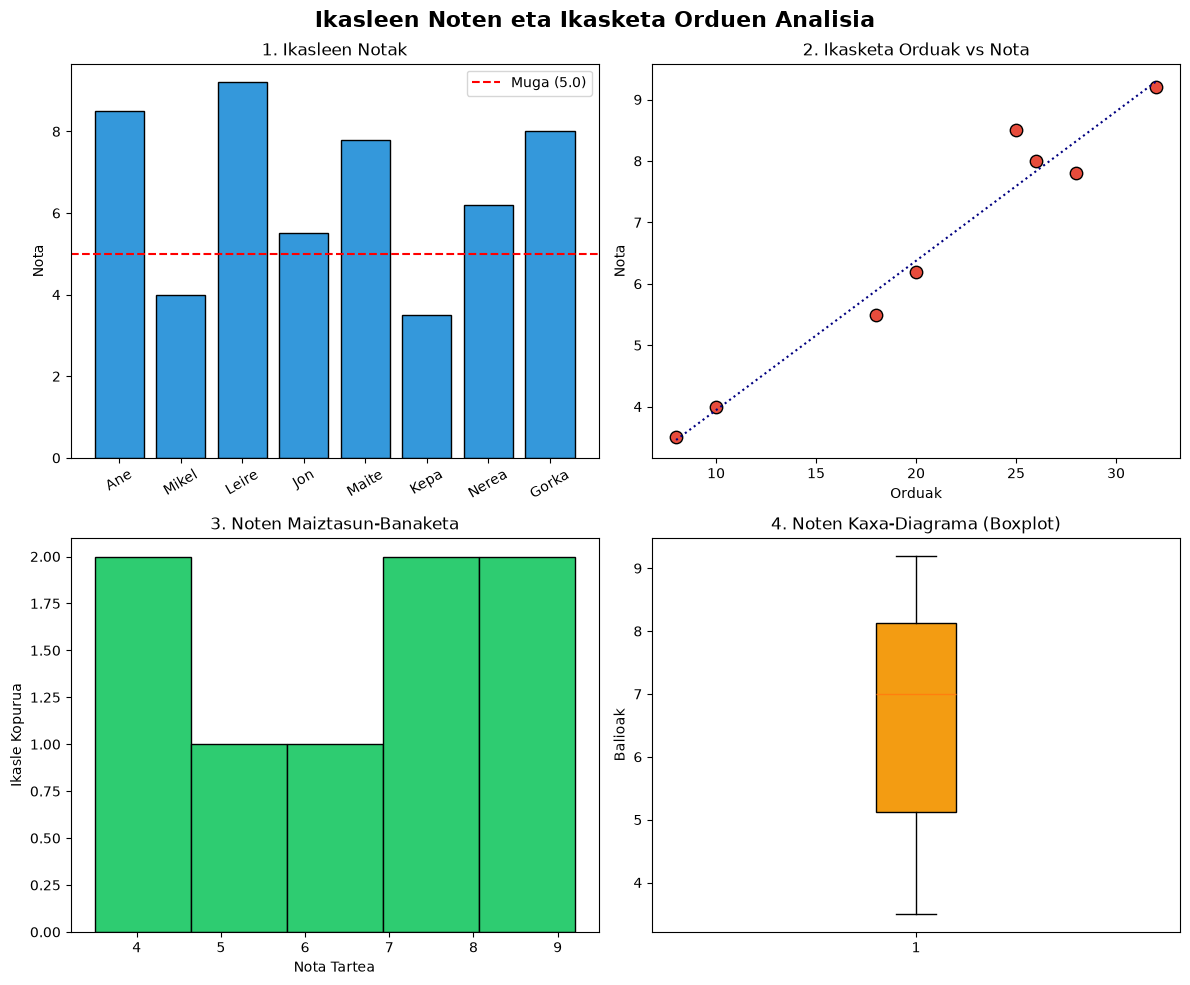

✅ Grafikoa 'grafikoak/grafikoa_3_1.png' eta 'grafikoak/grafikoa_3_1.pdf' gorde da.


/tmp/ipykernel_884347/1690712378.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[0, 1], palette="pastel")


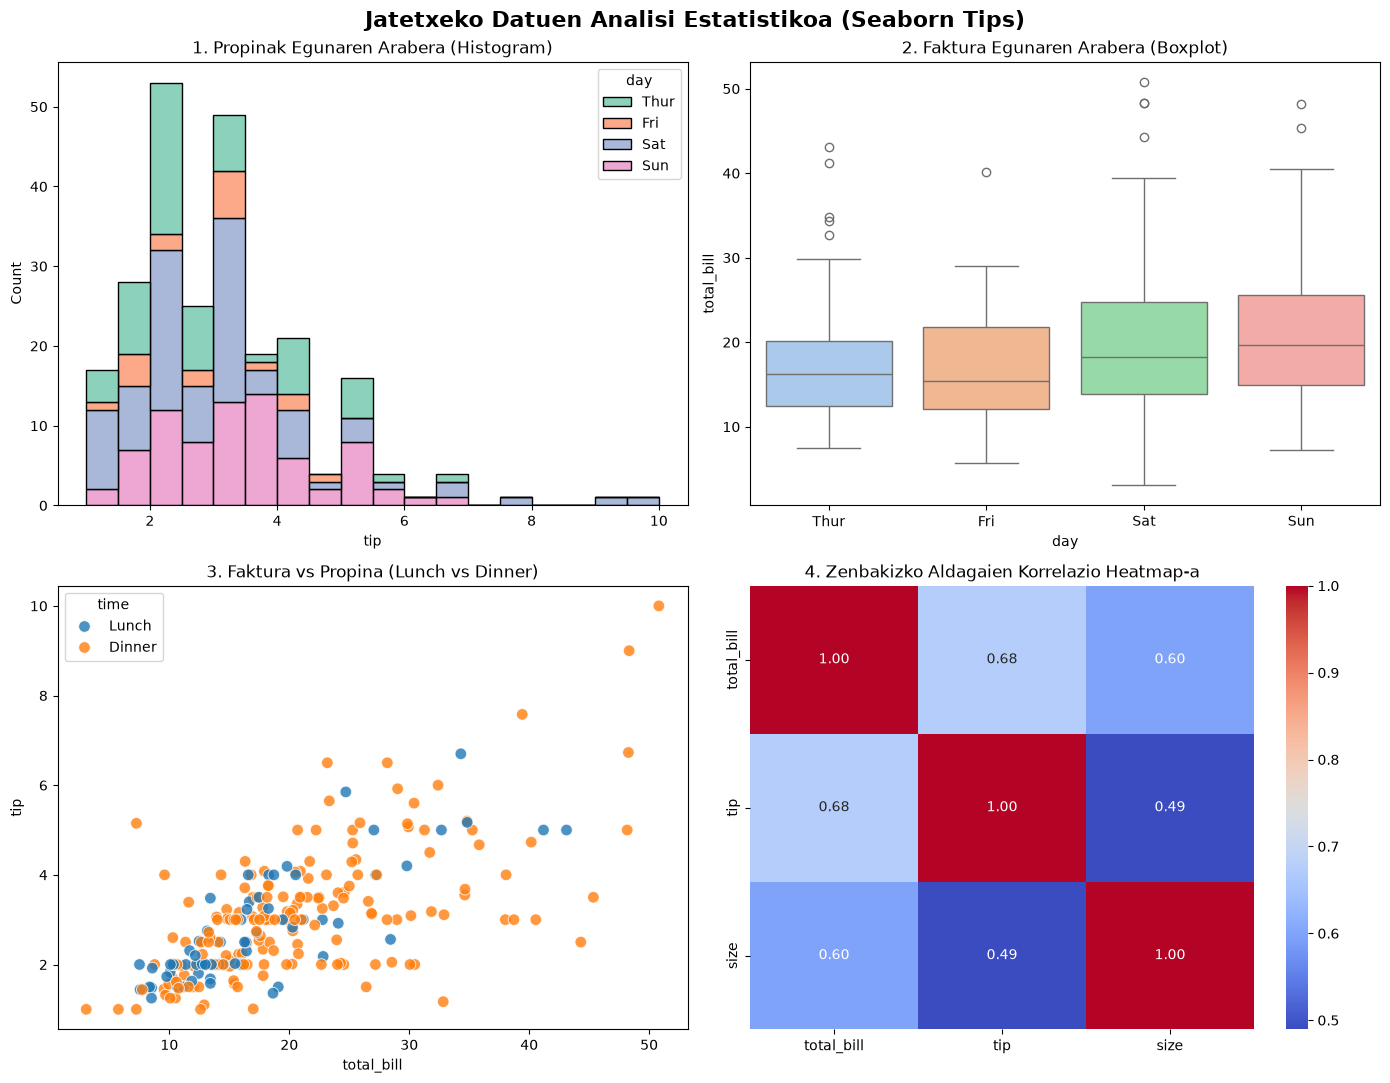

=== KORRELAZIOAREN ERANTZUNA ===
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000

💡 Galderaren erantzuna: Bi aldagai korrelazionatuenak 'total_bill' eta 'tip' dira (r = 0.68). Faktura zenbat eta handiagoa izan, orduan eta propina handiagoa ematen da normalean.


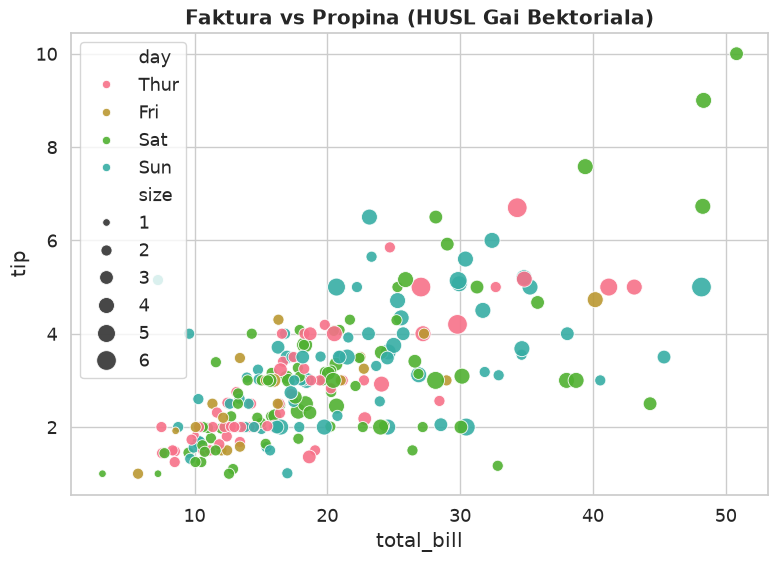

=== ARIKETA 3.3: FITXATEGI-TAMAINEN KONPARAKETA ===
            Formatua   Bereizmena  Tamaina (bytes)                                                     Erabilera Optimorik Hoberena
  PNG (Raster/Pixel)      300 DPI           339655                                      Web orriak, sare sozialak, txosten azkarrak
    PDF (Bektoriala) Eskalagarria            59616                Dokumentu formalak, inprimaketa profesionala, txosten akademikoak
SVG (Bektoriala XML) Eskalagarria           218389 Web aplikazio interaktiboak, nabigatzailean kalitate galerarik gabe zoom egiteko


=== ARIKETA 4.1: DVC FITXATEGIAREN EDUKIA ===
outs:
- md5: 51124ef5210fe0a2b81e487023609550
  size: 203
  hash: md5
  path: notak.csv



DVC Push egoera: 0 (Arrakastatsua)
Biltegi lokalean dauden fitxategiak: [PosixPath('/tmp/dvc-biltegia/files'), PosixPath('/tmp/dvc-biltegia/files/md5'), PosixPath('/tmp/dvc-biltegia/files/md5/51')]
=== ARIKETA 5.1: ENPRESEN GOMENDIO MATRIZEA ===

🏢 1. Startup Teknologikoa
   💡 Irtenbidea:   Python Open Source (FastAPI + Scikit-Learn + MLflow)
   🎯 Arrazoia:     Lizentzia-kosturik gabea (0 € hasieran), liburutegi modernoenetarako sarbide zuzena, eta arkitektura aldaketetara moldagarritasun handiena.
   ✅ Abantailak:   Malgutasun osoa, garatzaileen komunitate itzela, vendor lock-in eza.
   ⚠️ Desabantailak:Mantenua, segurtasun-konfigurazioa eta azpiegitura eskuz kudeatu behar dira.

🏢 2. Banketxe Handia
   💡 Irtenbidea:   Konbinazio Hibridoa (Azure ML Studio + Python Enterprise)
   🎯 Arrazoia:     Auditoretza zorrotza (MLOps gobernantza), sarbide-kontrolak (RBAC), datu-pribatutasuna (GDPR) eta ereduak erregulazio aurrean azaltzeko gaitasuna (Explainable AI).
   ✅ Abantailak:   Segurtasun

In [18]:
# Exekuzio osoa (gelaxkaz gelaxka edo script moduan)
main()
